<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt



In [10]:
df = pd.read_csv("ksaravan_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,delsuc_spike,00749be973f4145c4b5c085c1a5dc08ba30c74d4,Chiron <Chiron@localhost>,1441358966,correction on erroneous name with self\n,2015-09
1,delsuc_spike,007fd7f2b3b9db0fa22d335a3070e2485d490d46,MAD <madelsuc@unistra.fr>,1620122959,"improvement on documentation, and NMR Notebooks\n",2021-05
2,delsuc_spike,00ca02e9ff99183b75793796c8c45b9df922f95d,Marc-Andre' Delsuc <madelsuc@unistra.fr>,1444555855,seems to work fine !\n,2015-10
3,delsuc_spike,00f7f82c1a6cc30e789cd45edabcabc37723ed33,MAD <madelsuc@unistra.fr>,1639069505,improved spectral superimposing\n,2021-12
4,delsuc_spike,010058da3b5051eec4e135569164675d1bc50b9d,MA Delsuc <madelsuc@unistra.fr>,1495889086,modified the extract() command\n,2017-05


This notebook also contains the code from part 3 work after the work for part 2

In [11]:
prj='delsuc_spike'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [82]:
prj = 'delsuc_spike'

recent = df[df['project'] == prj].sort_values('time').tail(10)

for msg in recent['message']:
    print(msg)

added kilgour_sin apodisation

Merge 412538dbacfa317a5ca74c1c5085110a2fe54900 into 14d3c533ea067aec73ab1bda54464cf86298dfb8

added linewidth to contour display
minor bug correction in data arithmetics

added a bunch of small corrections - long overdue !

added copying peaks and integrals to data.copy()

initial commit for Fista algo - used for NUS processing

utility for Fista

corrected a bug when exporting empty data to Bruker format - thank you
Laura for pointing out

correction in comments

correction in import/export Bruker SMX files to follow numpy changes



In [12]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='w', header=True)

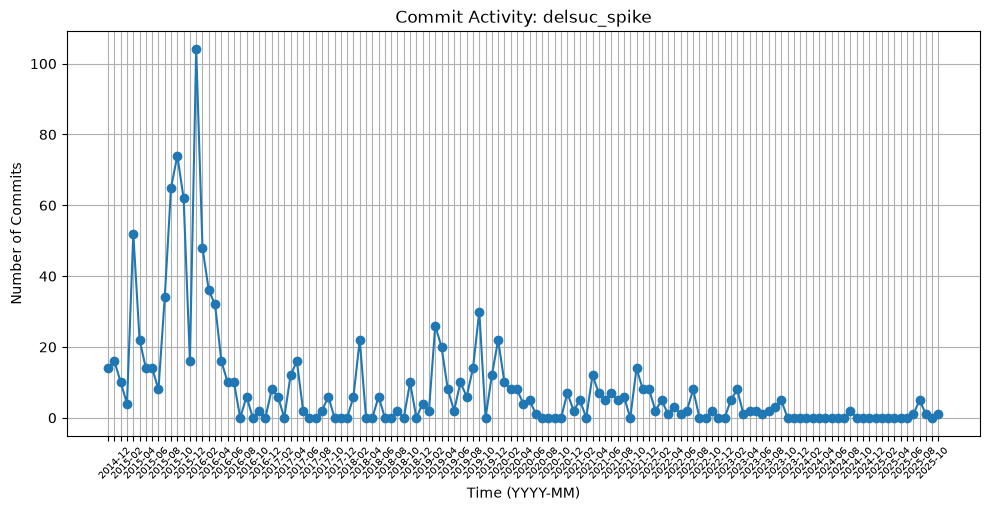

In [13]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [14]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2023-11
Longest Gap End: 2024-08
Longest Gap Length: 10
Number of gaps >= 3 months: 4


In [15]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: delsuc_spike
NumCommitsAfterLastGap: 10


In [16]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='w', header=True, index=False)
print(prj, "Before:", len(before), "After:", len(after))

delsuc_spike Before: 10 After: 10


In [78]:
prj='arm61_pylj'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [18]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

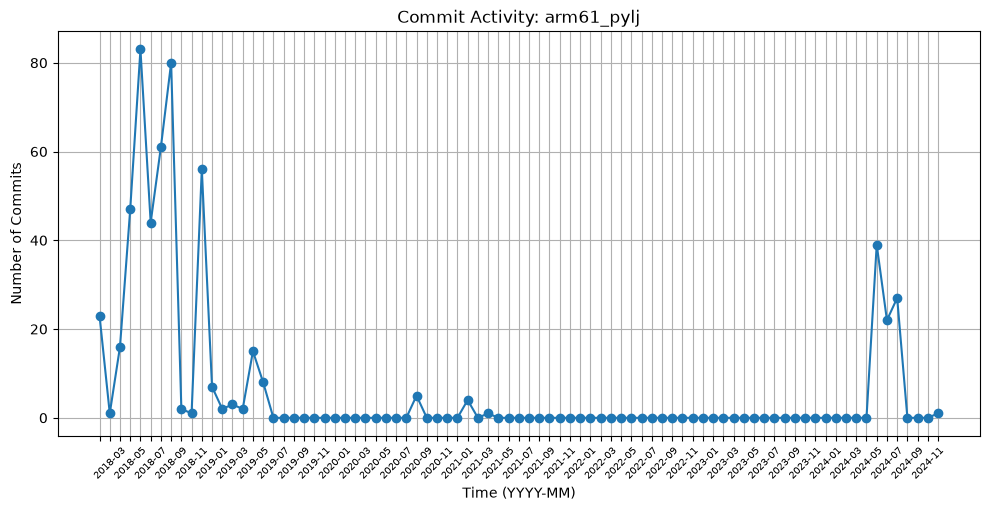

In [19]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [20]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2021-05
Longest Gap End: 2024-05
Longest Gap Length: 37
Number of gaps >= 3 months: 4


In [21]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: arm61_pylj
NumCommitsAfterLastGap: 89


In [22]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

arm61_pylj Before: 10 After: 10


In [23]:
prj='dswah_pygam'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [24]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

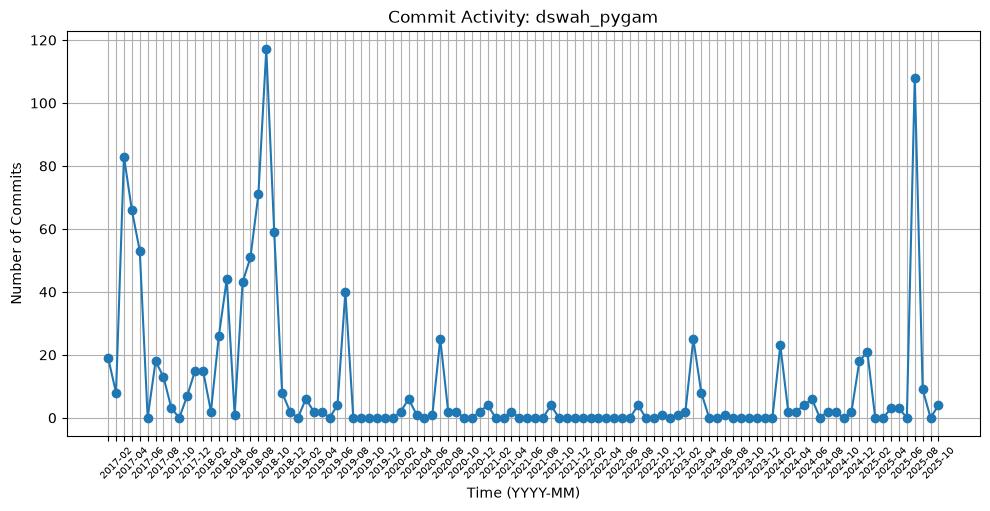

In [25]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [26]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2021-10
Longest Gap End: 2022-07
Longest Gap Length: 10
Number of gaps >= 3 months: 4


In [27]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: dswah_pygam
NumCommitsAfterLastGap: 251


In [28]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

dswah_pygam Before: 10 After: 10


In [29]:
prj='gyyang_neurogym'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [30]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

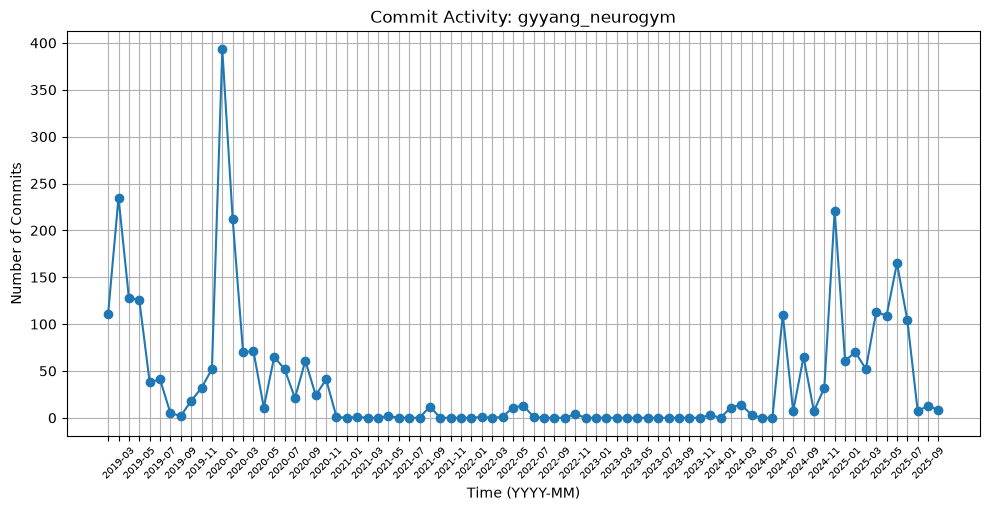

In [31]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [32]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2022-12
Longest Gap End: 2023-11
Longest Gap Length: 12
Number of gaps >= 3 months: 4


In [33]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: gyyang_neurogym
NumCommitsAfterLastGap: 1175


In [34]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

gyyang_neurogym Before: 10 After: 10


In [35]:
prj='jbytecode_linregoutliers'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [36]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

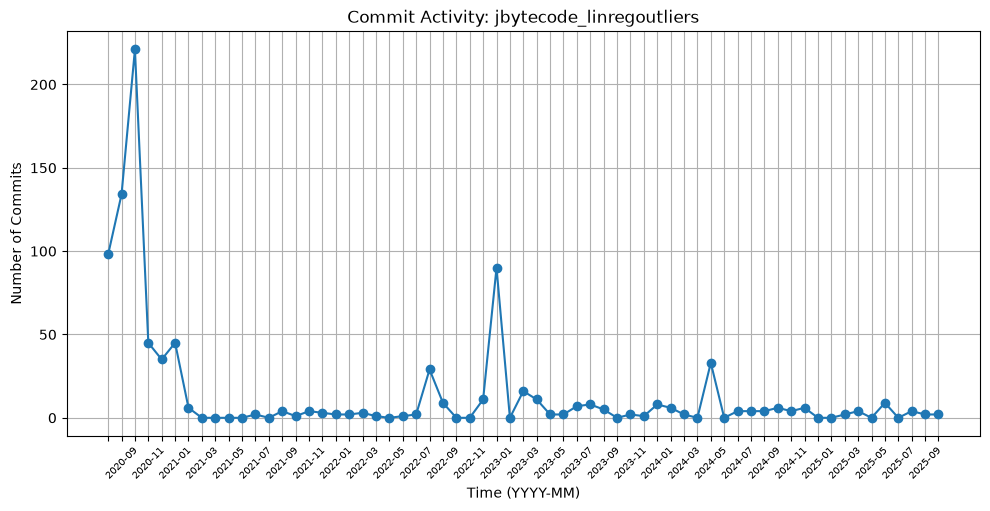

In [37]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [38]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2021-03
Longest Gap End: 2021-06
Longest Gap Length: 4
Number of gaps >= 3 months: 1


In [39]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: jbytecode_linregoutliers
NumCommitsAfterLastGap: 318


In [40]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

jbytecode_linregoutliers Before: 10 After: 10


In [41]:
prj='lsst_daf_butler'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [42]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

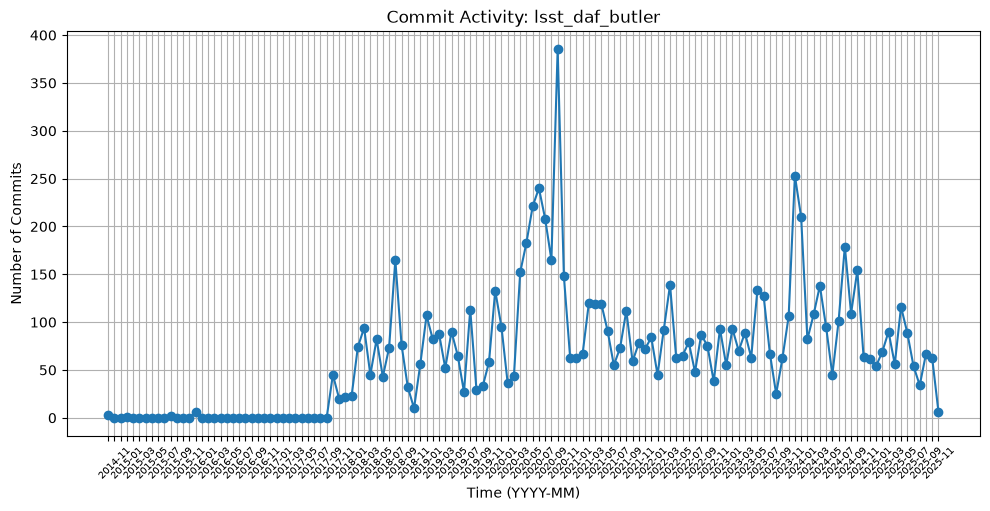

In [43]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [44]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2016-01
Longest Gap End: 2017-09
Longest Gap Length: 21
Number of gaps >= 3 months: 3


In [45]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: lsst_daf_butler
NumCommitsAfterLastGap: 8798


In [46]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

lsst_daf_butler Before: 10 After: 10


In [47]:
prj='mothur_mothur'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [48]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

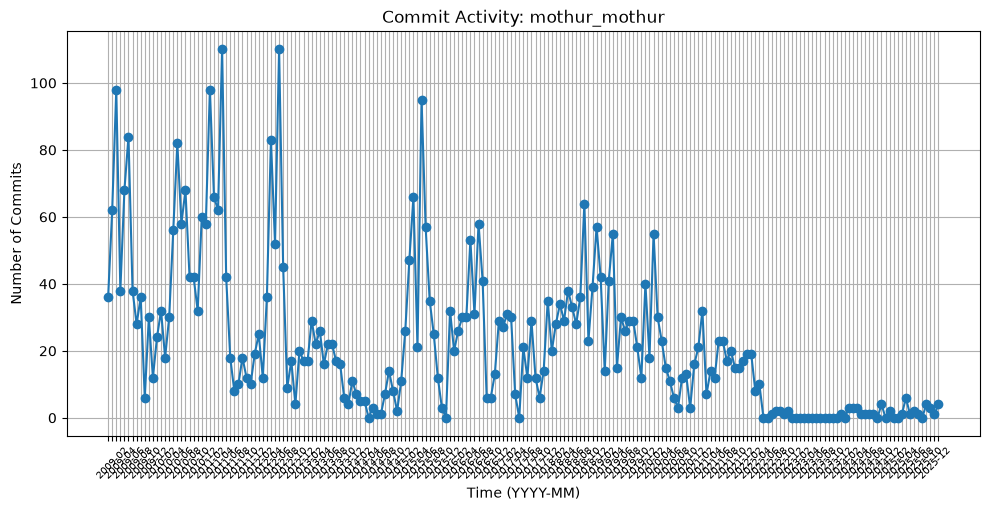

In [49]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [50]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2023-01
Longest Gap End: 2023-12
Longest Gap Length: 12
Number of gaps >= 3 months: 1


In [51]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: mothur_mothur
NumCommitsAfterLastGap: 43


In [52]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

mothur_mothur Before: 10 After: 10


In [53]:
prj='nasa_ccdd'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [54]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

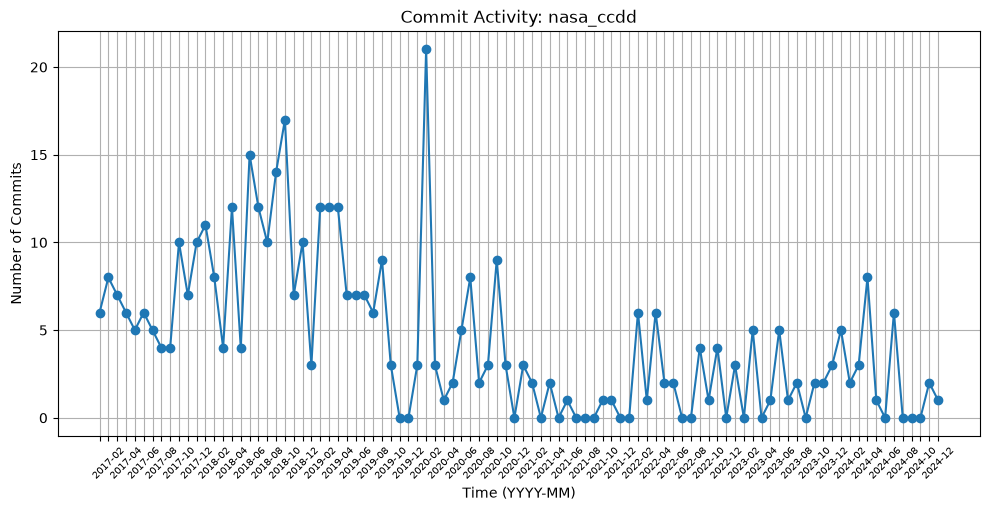

In [55]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [56]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2021-07
Longest Gap End: 2021-09
Longest Gap Length: 3
Number of gaps >= 3 months: 2


In [57]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: nasa_ccdd
NumCommitsAfterLastGap: 80


In [58]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

nasa_ccdd Before: 10 After: 10


In [59]:
prj='papenfusslab_gridss'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [60]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

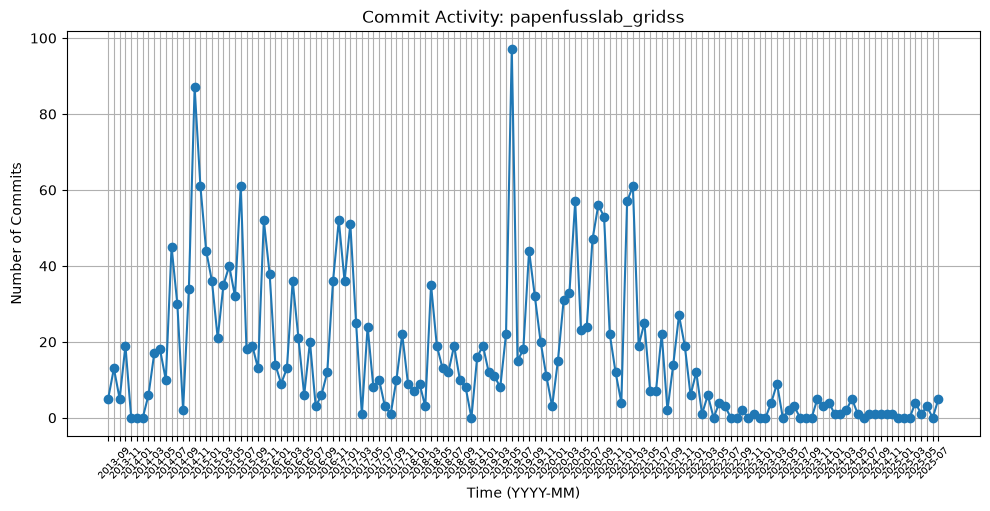

In [61]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [62]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2013-12
Longest Gap End: 2014-02
Longest Gap Length: 3
Number of gaps >= 3 months: 3


In [63]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: papenfusslab_gridss
NumCommitsAfterLastGap: 2340


In [64]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

papenfusslab_gridss Before: 10 After: 10


In [65]:
prj='stephenslab_mashr'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


In [66]:
monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
out = monthly_counts[['Month', 'Commits']].copy()
out.rename(columns={'Commits': '#Commits'}, inplace=True)
out['Project'] = prj
out.to_csv('ksaravan_commits_timeseries.csv', sep=';', index=False, mode='a', header=False)

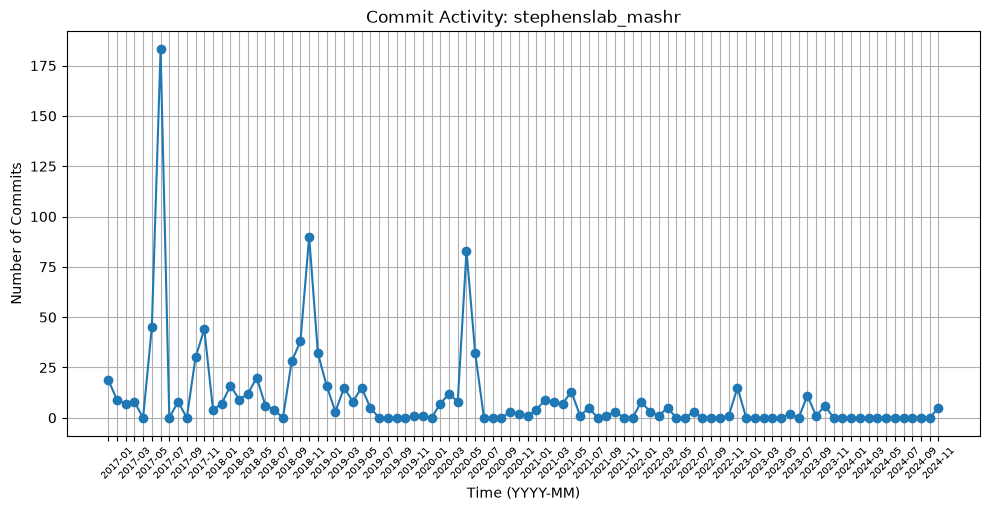

In [67]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("ksaravan_timeseries_"+prj+".png", dpi=300)
plt.show()
plt.close()

In [68]:
zero = monthly_counts['Commits'].eq(0)

groups = zero.ne(zero.shift()).cumsum()

gaps = monthly_counts[zero].groupby(groups[zero]).agg(
    Start=('Month', 'first'),
    End=('Month', 'last'),
    Length=('Month', 'size')
)

if len(gaps) > 0:
    longest = gaps.loc[gaps['Length'].idxmax()]

    print("Longest Gap Start:", longest['Start'])
    print("Longest Gap End:", longest['End'])
    print("Longest Gap Length:", longest['Length'])
else:
    print("No inactivity gaps")

print("Number of gaps >= 3 months:", (gaps['Length'] >= 3).sum())

Longest Gap Start: 2023-11
Longest Gap End: 2024-10
Longest Gap Length: 12
Number of gaps >= 3 months: 5


In [69]:
commits_after_gap = monthly_counts.loc[
    monthly_counts['Month'] > longest['End'],
    'Commits'
].sum()

print("Project:", prj)
print("NumCommitsAfterLastGap:", commits_after_gap)

Project: stephenslab_mashr
NumCommitsAfterLastGap: 5


In [70]:
project_commits = df[df['project'] == prj].copy()
project_commits['commit_date'] = pd.to_datetime(project_commits['time'], unit='s')
start = pd.Period(longest['Start'], freq='M').start_time
end = pd.Period(longest['End'], freq='M').end_time

before = project_commits[project_commits['commit_date'] < start].sort_values('time').tail(10).copy()
after = project_commits[project_commits['commit_date'] > end].sort_values('time').head(10).copy()

before['pre/post'] = 'pre'
after['pre/post'] = 'post'
selected = pd.concat([before, after])
selected = selected.rename(columns={'commit_sha1': 'commit', 'project_wocid': 'project', 'commit message': 'message'})
selected = selected[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
selected.to_csv('ksaravan_project_gap_commits.csv', sep=';', mode='a', header=False, index=False)
print(prj, "Before:", len(before), "After:", len(after))

stephenslab_mashr Before: 10 After: 5


# Identify the Longest Inactivity Gap (completed above)

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

## Interpretation

Delsuc_spike:

The trend of the commits is a declining graph as there seems to be a lot activity in the beginning of the project and it gradually declines. This tell us that people did a lot of work as soon as the project started, but slowly reduced their efforts to nearly negligible in the last two years of the project. There are 4 different gaps of inactivity, where there were no commits for 3 months straight.

arm61_pylj:

The trend of this graph is mostly declining as there are some activity in the first few months, and it completely reduced to very few commits or 0 in the next few years. However, there are slight spikes in last few months. So, this could be an abandoned project for a long time that had final checkings in the last few months. There is 4 different gaps of inactivity with no commits for 3 months.

dswah_pyGAM:

There is high irregularities in the commit graph throughout the time period as we can see that during the initial time period, there are few commits, some areas with no progress, sudden spikes, and similar irregularities throughout. We cannot assume anything much about the work, but we can maybe say that the project was not completely abandoned, and at the same time, it was not always being worked. This graph showed 4 different gaps of inactivity too.

gyyang_neurogym:

The commit graph showed a U-shaped trend. This tells us the when the project started, there so much progress going on. However, the progress was not consistent as there could have been periods where people stopped working on the project. In the end, there is another set of huge progress shown like the beginning. So, this could be the period where final checks were made before finalizing the project. Again, even this project, had 4 different gaps of inactivity in between. So, it was not entirely abandoned in between as there were few commits made every now and then, but they were not a lot of project.

jbytecode_LinRegOutliers:

The graph shows a declining trend as the only huge progress done was during the beginning. After that, there were consistent efforts made, but they had really reduced commits throughout. Compared to the other projects, this seems slightly better as the project is not completely abondoned in the middle. Also, there is only 1 gap where there was no commits for 3 months straight. So, it has been pretty consistent in commits, but with reducing intensity.

lsst_daf_butler:

The graph depicts a cyclic pattern after series of no activity. After 2017, there is upward and downward spikes throughout the time period. This tells us that the project did not follow a straightforward pattern, but instead, it had repeated patterns of ups and downs. So, we can say that people were constantly working on the project with months of high and comparatively low activities. There are overall 3 gaps in the timeline with not much activity at all.

mothur_mothur:

This graph also shows a cyclic pattern like the previous project. However, it changes in the way when the repeated activity has happened. In this project, the cyclic pattern shows up in the beginning of the project than the second half like last time. After 2022, there has been reduced or negligible actibity. So, contributors were working constantly, with very slight irregularities, in the beginning of the project. However, progress reduced after 2022. Also, there is only 1 gap of inactivity, so even in the end, people were still keeping up.

nasa_CCDDD:

The graph demostrates an irregular commit pattern throughout the time period. There are sudden spikes of high commits all over the place, but still filled with lower spikes in random spots. This tells us that the project was making some progress throughout, but still it was not consistent or predictable. There are 2 gaps of inactivity throughout, thereby, telling us there were still few points of inactivity.

PapenfussLab_gridss:

For the most part, this graph shows an U-shaped commit history. The pattern starts during the beginning of the project and goes until 2022. So, the U-shape pattern clearly tells us the people most likely worked a lot during the beginning and ending of the project season, with still some slight progress in between. But interestingly, after 2022, there is not much activity or a pattern in commits. Also, there were 3 gaps of inactivity throughout.

stephenslab_mashr:

The graph depicts an irregular pattern for the commit history. There are sudden spikes in the graph, showing high progress rarely. But in most of the other cases, it has less than 15 commits throughout. So, this could be a project where the high progress was randomly done, and in other times, slight updates were made throughout. There are 5 gaps of inactivity, which is the largest compared to other projects. So, the progress seems to be highly irregular